In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from disba import PhaseDispersion
#import project_utils.py

In [10]:
def forward_model(thickness, vp, vs, rho, period):
    # Creates a PhaseDispersion object - gives 1D velocity based on thickness/vs/vp/density
    pd = PhaseDispersion(thickness, vp, vs, rho)
    return pd(period, mode=0, wave="rayleigh")

## True Model
Assumed 2 layers and a half space to start


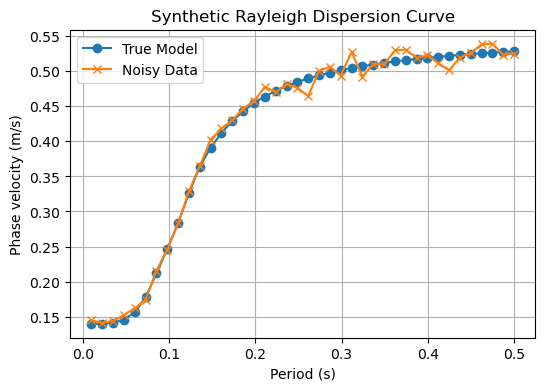

In [60]:
# units per disba documentation
# thickness (km)
thickness = [0.005, 0.010, 0]

# s-wave p-wave velocities (km/s)
vs_true = [.150, .300, 0.600]
vp_true = [.300, .600, 1.200]
# density (g/cm^3)
rho = [1.8, 1.9, 2.0]
# period[s]
period = np.linspace(0.01, 0.5, 40)

truemodel = forward_model(thickness, vp_true, vs_true, rho, period)

np.random.seed(0) # this keeps the random noise from not changing every time so we can troubleshoot more easily

dobs = truemodel.velocity
noise_level = 0.02
dobs_noisy= dobs + noise_level * dobs * np.random.randn(len(dobs))

T = truemodel.period

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Synthetic Rayleigh Dispersion Curve")
plt.grid(True)
plt.legend()
plt.show()

In [61]:
def objective_function(beta, dpred, dobs, vs):
    phi_d = np.sum((dpred - dobs)**2)
    phi_m = np.sum(np.diff(vs)**2)
    phi = phi_d + beta * phi_m

    return phi, phi_d, phi_m

## First Trial


In [62]:
thickness_first = [0.005, 0.010, 0.0] # fix for now - vary vs (perhaps change later)
vs_first = [0.18, 0.25, 0.50] # initial guess for Vs (km/s)
vp_first = [2*v for v in vs_first] # assume p-waves are 2x s-waves (generally true)
rho_first = [1.8, 1.9, 2.0] # minor impact on model, so assumed constant for now)

In [63]:
beta_first = 0.5 # regularization parameter - constant for now

dpred_first = forward_model(thickness_first, vp_first, vs_first, rho_first, period).velocity
obj_first = objective_function(beta_first, dpred_first, dobs_noisy, vs_first)


phi_first, phi_d_first, phi_m_first = objective_function(
    beta_first, dpred_first, dobs_noisy, vs_first)

## Steepest Descent / Gradient


In [64]:
def gradient_function(vs, thickness, rho, period, dobs, beta, dx=1e-4):
# Taking a small step in a direction to determine gradient of objective function
    vp = [2*v for v in vs]
    dpred = forward_model(thickness, vp, vs, rho, period).velocity
    phi0, _, _ = objective_function(beta, dpred, dobs, vs)
    grad = [0.0] * len(vs)

    for i in range(len(vs)):
        #loops for the dimension of vs and adds a small dx to each component
        vs_trial = vs.copy()
        vs_trial[i] += dx
        vp_trial = [2*v for v in vs_trial]
        dpred_trial = forward_model(thickness, vp_trial, vs_trial, rho, period).velocity
        phi1, _, _= objective_function(beta, dpred_trial, dobs, vs_trial)
        grad[i] = (phi1 - phi0) / dx
    return grad

In [65]:
def step_function(grad_vs1, grad_vs2, step, vs):
    #for 2 shear wave velocity system
    # no negative swave velocities - minimum 0.05 km/s (arbitrary)
    vs_new = [
        max(vs[0] - step * grad_vs1, 0.05),
        max(vs[1] - step * grad_vs2, 0.05),
        vs[2]
    ]
    vp_new = [2*v for v in vs_new]
    return vs_new, vp_new

In [66]:
# while loop settings
step0 = 1e-2
i = 0
max_iter = 30
tol_phi = 1e-3
vs_current = vs_first.copy()
phi_current = phi_first
phi_diff = 999

while (phi_diff > tol_phi) and (i < max_iter):
# halves the step until phi does not change much anymore (tol_phi)
    i += 1
    step = step0 #reset the steps at start of iteration
    n_half = 0 # counter for step halving

    grad_current = gradient_function(vs_current, thickness_first, rho_first, period, dobs_noisy, beta_first)

    while n_half < 10: 
        vs_trial_new, vp_trial_new = step_function(grad_current[0], grad_current[1], step, vs_current)
        dpred_new = forward_model(thickness_first, vp_trial_new, vs_trial_new, rho_first, period).velocity
        phi_new, phi_d_new, phi_m_new = objective_function(beta_first, dpred_new, dobs_noisy, vs_trial_new)
        # took a step and then calculated objective function
        print(f"Iteration {i}: step={step:.2e}, phi={phi_new:.3e}, vs={vs_trial_new}")
    
        if phi_new < phi_current:
            #checks phi_new is smaller than phi_current and accepts changes if so
            phi_diff = abs(phi_new - phi_current)
            vs_current = vs_trial_new
            vp_current = vp_trial_new
            dpred_current = dpred_new
            phi_current = phi_new
            print(f"step accepted. phi_diff={phi_diff:.3e}")
            break
        #if phi_new > phi_current, spit the step and go again.
        step *= 0.5
        n_half += 1
        print(f"step failed. step={step:.3e}")
    if n_half == 10:
        print("No acceptable step found.")
        break

Iteration 1: step=1.00e-02, phi=2.284e-01, vs=[np.float64(0.18818137873953017), np.float64(0.270814741677766), 0.5]
step accepted. phi_diff=3.831e-02
Iteration 2: step=1.00e-02, phi=2.156e-01, vs=[np.float64(0.19146820702665474), np.float64(0.28276112988710445), 0.5]
step accepted. phi_diff=1.279e-02
Iteration 3: step=1.00e-02, phi=2.094e-01, vs=[np.float64(0.19259048396666795), np.float64(0.2911145245636624), 0.5]
step accepted. phi_diff=6.157e-03
Iteration 4: step=1.00e-02, phi=2.058e-01, vs=[np.float64(0.19248683381044335), np.float64(0.29741333768404077), 0.5]
step accepted. phi_diff=3.594e-03
Iteration 5: step=1.00e-02, phi=2.034e-01, vs=[np.float64(0.1915798084010854), np.float64(0.3024513953407413), 0.5]
step accepted. phi_diff=2.465e-03
Iteration 6: step=1.00e-02, phi=2.014e-01, vs=[np.float64(0.19023005769799078), np.float64(0.30674440351426113), 0.5]
step accepted. phi_diff=1.930e-03
Iteration 7: step=1.00e-02, phi=1.998e-01, vs=[np.float64(0.18862498179547144), np.float64(0.

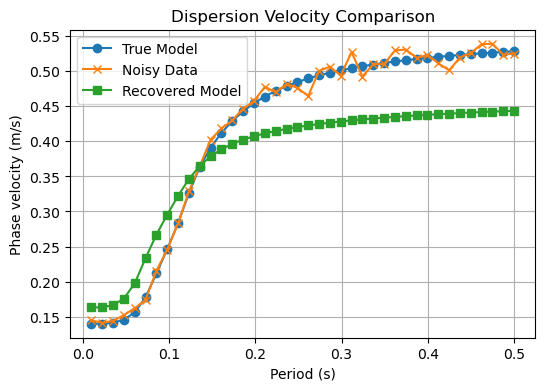

'\nDecent result. The mismatch is because our code does not currently invert Vs3 (half space). \nThus the model does not update Vs3 from the initial guess (0.5), which differs from the true value (0.6).\nIt makes sense that the larger period is affected as the deeper layer will have influence there.\n'

In [67]:
dpred_final = dpred_current.copy()

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.plot(T, dpred_final, marker="s", label="Recovered Model")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Dispersion Velocity Comparison")
plt.grid(True)
plt.legend()
plt.show()

'''
Decent result. The mismatch is because our code does not currently invert Vs3 (half space). 
Thus the model does not update Vs3 from the initial guess (0.5), which differs from the true value (0.6).
It makes sense that the larger period is affected as the deeper layer will have influence there.
'''


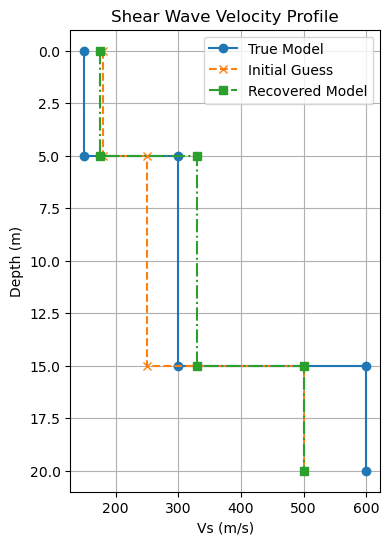

In [73]:
vs_true #true
vs_first #starting point
vs_final = vs_current.copy() #recovered

depth1 = thickness_first[0]
depth2 = depth1 + thickness_first[1]
depth3 = depth2 + 0.005 # halfspace

depth = [0, depth1, depth2, depth3]

def step_Vsplot(vs, depth):
    vs_plot =[vs[0], vs[0], vs[1], vs[1], vs[2], vs[2]]
    depth_plot = [depth[0], depth[1], depth[1], depth[2], depth[2], depth[3]]
    return vs_plot, depth_plot

# stepped velocity profile
vs_true_plot, depth_true_plot = step_Vsplot(vs_true, depth)
vs_first_plot, depth_first_plot = step_Vsplot(vs_first, depth)
vs_final_plot, depth_final_plot = step_Vsplot(vs_final, depth)

# convert to meters (more common than km)
vs_true_plot = [v * 1000 for v in vs_true_plot]
vs_first_plot = [v * 1000 for v in vs_first_plot]
vs_final_plot = [v * 1000 for v in vs_final_plot]
depth_true_plot = [d * 1000 for d in depth_true_plot]
depth_first_plot = [d * 1000 for d in depth_first_plot]
depth_final_plot = [d * 1000 for d in depth_final_plot]

plt.figure(figsize=(4,6))
plt.plot(vs_true_plot, depth_true_plot, label="True Model", marker="o")
plt.plot(vs_first_plot, depth_first_plot, label="Initial Guess", ls="--", marker="x")
plt.plot(vs_final_plot, depth_final_plot, label="Recovered Model", ls="-.", marker="s")
plt.gca().invert_yaxis()
plt.xlabel("Vs (m/s)")
plt.ylabel("Depth (m)")
plt.title("Shear Wave Velocity Profile")
plt.grid(True)
plt.legend()
plt.show()
